In [10]:
import gdown
import pandas as pd
url1 = 'https://drive.google.com/uc?id=1fYGb-n114IGWZDcBKE0jzc3BWSLCcsVQ'
gdown.download(url1, 'data1.csv', quiet=False)
url2 = 'https://drive.google.com/uc?id=1eX9an3tSypvrFn_fiPReYHTca5GpJaJG'
gdown.download(url2, 'data2.csv', quiet=False)

df1 = pd.read_csv('data1.csv')
df2 = pd.read_csv('data2.csv')

Downloading...
From (original): https://drive.google.com/uc?id=1fYGb-n114IGWZDcBKE0jzc3BWSLCcsVQ
From (redirected): https://drive.google.com/uc?id=1fYGb-n114IGWZDcBKE0jzc3BWSLCcsVQ&confirm=t&uuid=f0d393ef-4cb6-4081-9cd9-a86634c6b7a2
To: /content/data1.csv
100%|██████████| 794M/794M [00:29<00:00, 27.1MB/s]
Downloading...
From: https://drive.google.com/uc?id=1eX9an3tSypvrFn_fiPReYHTca5GpJaJG
To: /content/data2.csv
100%|██████████| 6.16k/6.16k [00:00<00:00, 10.7MB/s]


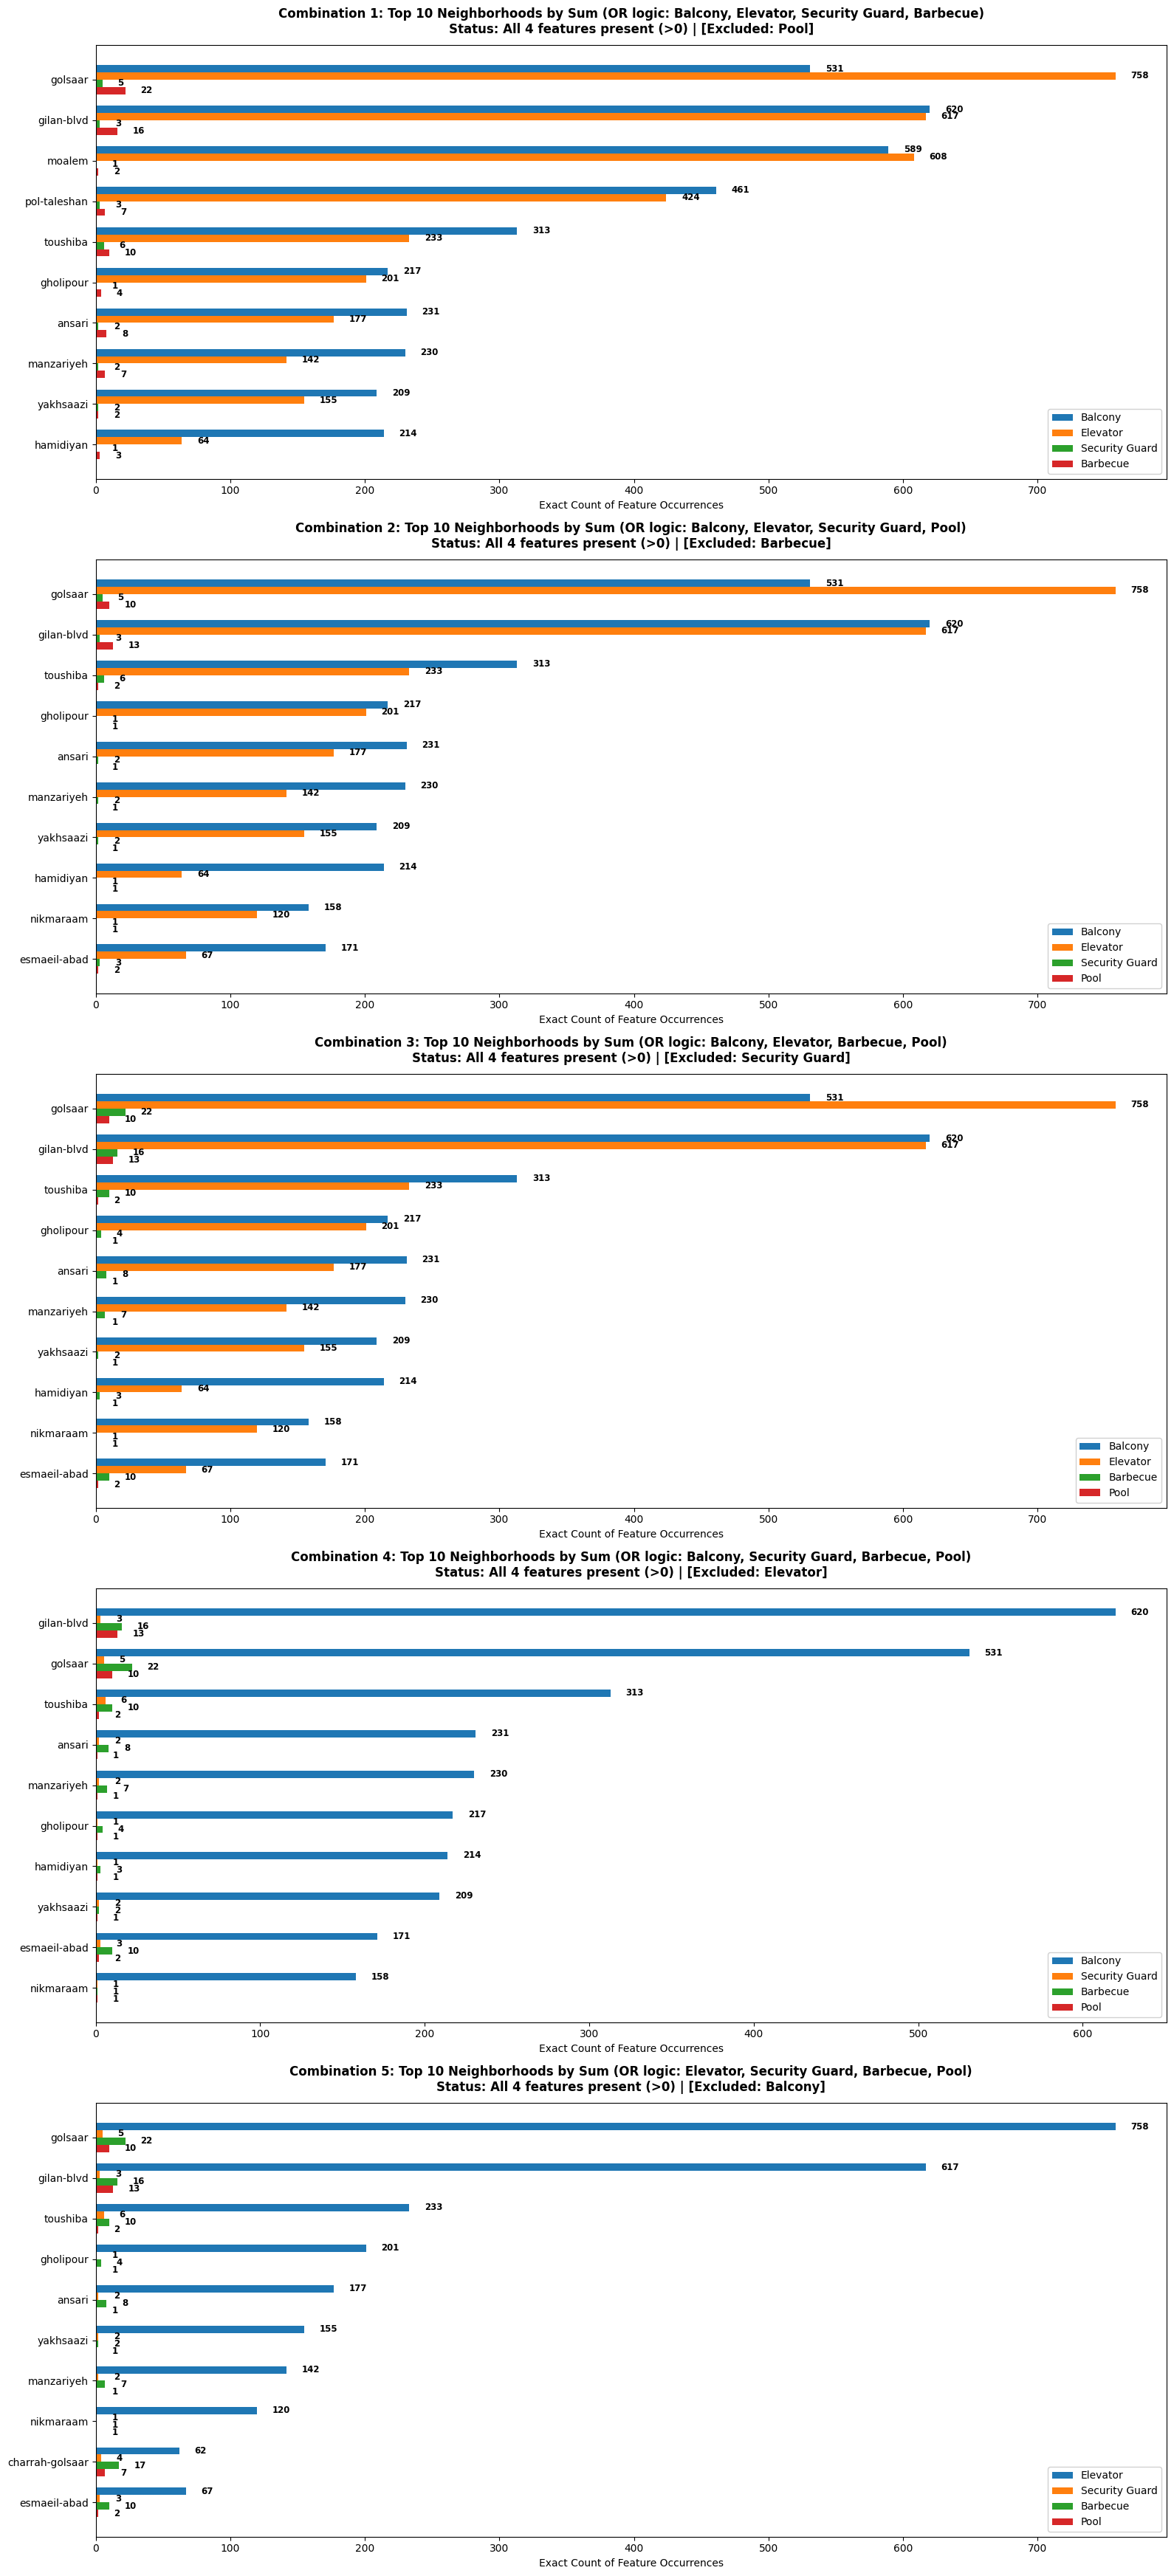

In [ ]:

import itertools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
features = [
    'has_balcony',
    'has_elevator',
    'has_security_guard',
    'has_barbecue',
    'has_pool',
]

feature_names_en = {
    'has_balcony': 'Balcony',
    'has_elevator': 'Elevator',
    'has_security_guard': 'Security Guard',
    'has_barbecue': 'Barbecue',
    'has_pool': 'Pool',
}


df_clean = df1.copy()
truthy_values = [True, 'True', 'true', 'TRUE', 1, 1.0, '1', 'دارد']

for col in features:
  if col in df_clean.columns:
    df_clean[col] = df_clean[col].isin(truthy_values).astype(int)
  else:
    df_clean[col] = 0
df_clean = df_clean.dropna(subset=['neighborhood_slug'])
df_clean['neighborhood_slug'] = (
    df_clean['neighborhood_slug'].astype(str).str.strip()
)
df_clean = df_clean[df_clean['neighborhood_slug'] != '']

distinct_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

combinations = list(itertools.combinations(features, 4))

fig, axes = plt.subplots(5, 1, figsize=(16, 35))
plt.subplots_adjust(hspace=0.55)

for idx, comb in enumerate(combinations):
  comb_list = list(comb)
  excluded_feature = list(set(features) - set(comb))[0]
  grouped_all = df_clean.groupby('neighborhood_slug')[comb_list].sum()
  valid_4_features = grouped_all[(grouped_all > 0).all(axis=1)]

  if len(valid_4_features) >= 10:
    top_neighborhoods = (
        valid_4_features.sum(axis=1).nlargest(10).index
    )
    subtitle_status = "All 4 features present (>0)"
  else:

    at_least_3 = grouped_all[(grouped_all > 0).sum(axis=1) >= 3]
    top_neighborhoods = at_least_3.sum(axis=1).nlargest(10).index
    subtitle_status = "Fallback: At least 3 features present (some can be 0)"

  if len(top_neighborhoods) == 0:
    axes[idx].text(
        0.5,
        0.5,
        'No suitable neighborhoods found',
        ha='center',
        va='center',
        fontsize=14,
    )
    continue


  grouped_data = grouped_all.loc[top_neighborhoods]

  y_labels = list(grouped_data.index)
  y_pos = np.arange(len(y_labels))
  bar_height = 0.18

  for feat_idx, feat in enumerate(comb_list):
    offset = (feat_idx - 1.5) * bar_height
    values = grouped_data[feat].values

    bars = axes[idx].barh(
        y_pos + offset,
        values,
        height=bar_height,
        label=feature_names_en[feat],
        color=distinct_colors[feat_idx],
    )

    for bar in bars:
      width = bar.get_width()
      max_val = max(grouped_data.max()) if max(grouped_data.max()) > 0 else 1
      axes[idx].text(
          width + (max_val * 0.015),
          bar.get_y() + bar.get_height() / 2,
          f'{int(width):,}',
          va='center',
          ha='left',
          fontsize=8.5,
          fontweight='bold',
      )

  comb_en_names = [feature_names_en[c] for c in comb_list]
  title_str = (
      f'Combination {idx + 1}: Top 10 Neighborhoods by Sum (OR logic:'
      f' {", ".join(comb_en_names)})\nStatus: {subtitle_status} | [Excluded:'
      f' {feature_names_en[excluded_feature]}]'
  )

  axes[idx].set_title(title_str, fontsize=12, fontweight='bold', pad=12)
  axes[idx].set_yticks(y_pos)
  axes[idx].set_yticklabels(y_labels, fontsize=10)
  axes[idx].invert_yaxis()
  axes[idx].set_xlabel('Exact Count of Feature Occurrences', fontsize=10)
  axes[idx].legend(loc='lower right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

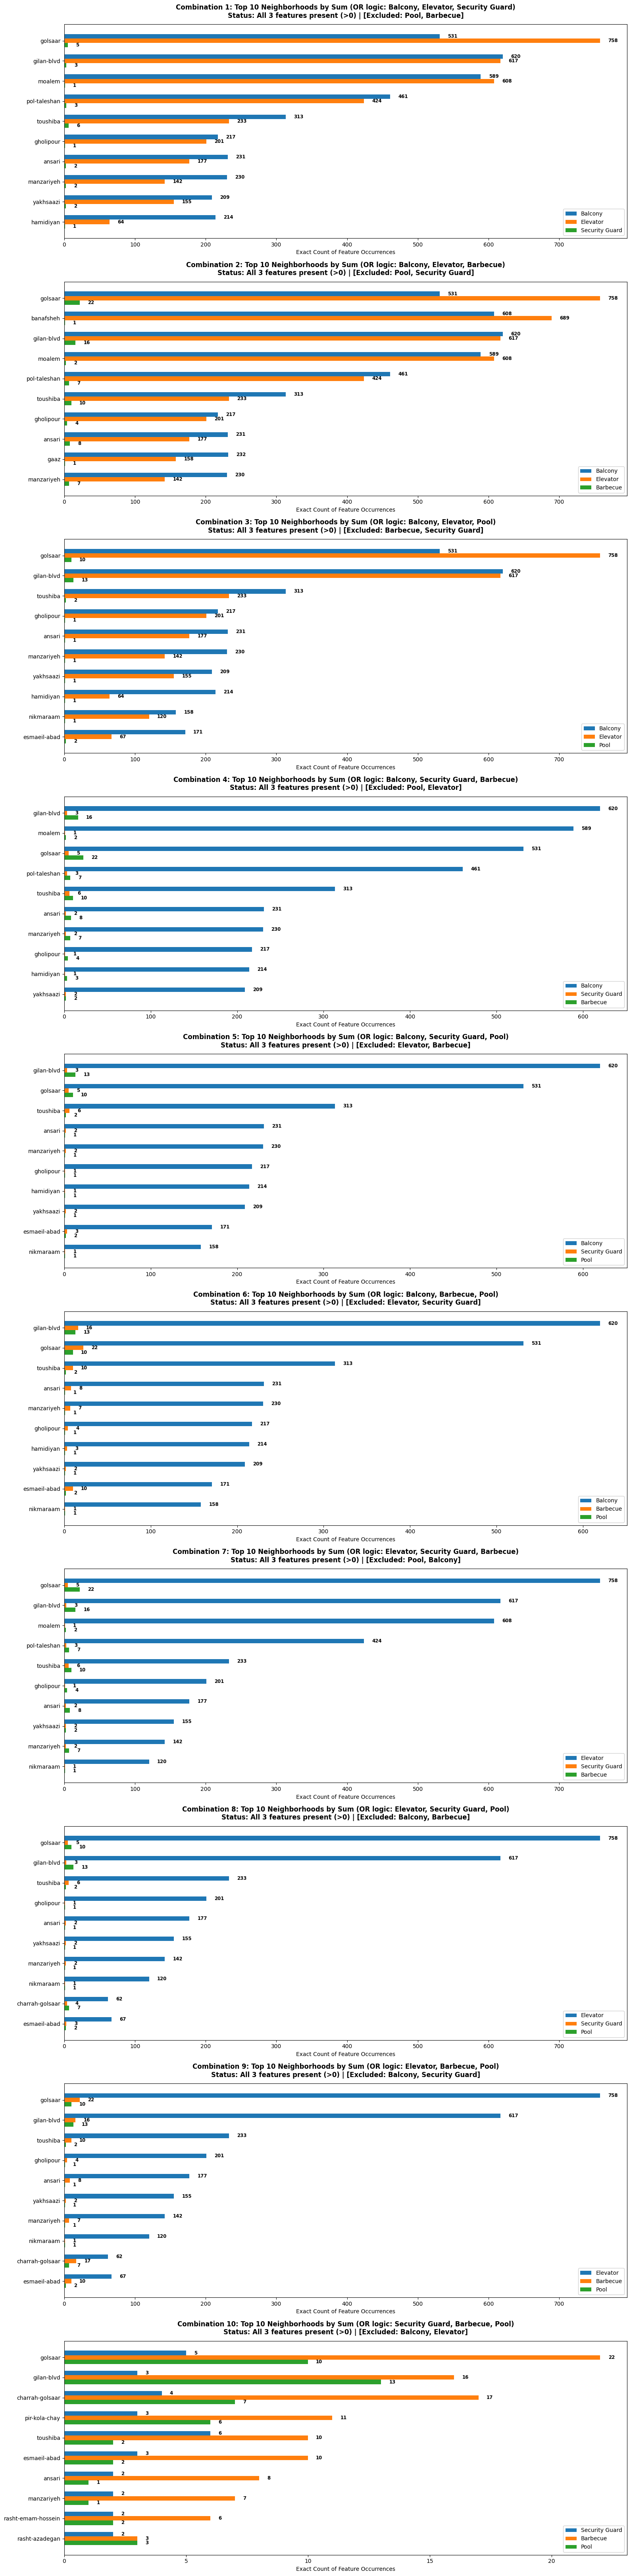

In [24]:

import itertools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
features = [
    'has_balcony',
    'has_elevator',
    'has_security_guard',
    'has_barbecue',
    'has_pool',
]

feature_names_en = {
    'has_balcony': 'Balcony',
    'has_elevator': 'Elevator',
    'has_security_guard': 'Security Guard',
    'has_barbecue': 'Barbecue',
    'has_pool': 'Pool',
}

df_clean = df1.copy()
truthy_values = [True, 'True', 'true', 'TRUE', 1, 1.0, '1', 'دارد']

for col in features:
  if col in df_clean.columns:
    df_clean[col] = df_clean[col].isin(truthy_values).astype(int)
  else:
    df_clean[col] = 0

df_clean = df_clean.dropna(subset=['neighborhood_slug'])
df_clean['neighborhood_slug'] = (
    df_clean['neighborhood_slug'].astype(str).str.strip()
)
df_clean = df_clean[df_clean['neighborhood_slug'] != '']
distinct_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
combinations = list(itertools.combinations(features, 3))
fig, axes = plt.subplots(10, 1, figsize=(16, 65))
plt.subplots_adjust(hspace=0.55)
for idx, comb in enumerate(combinations):
  comb_list = list(comb)
  excluded_features = list(set(features) - set(comb))

  grouped_all = df_clean.groupby('neighborhood_slug')[comb_list].sum()
  valid_3_features = grouped_all[(grouped_all > 0).all(axis=1)]

  if len(valid_3_features) >= 10:

    top_neighborhoods = (
        valid_3_features.sum(axis=1).nlargest(10).index
    )
    subtitle_status = "All 3 features present (>0)"
  else:
    at_least_2 = grouped_all[(grouped_all > 0).sum(axis=1) >= 2]
    top_neighborhoods = at_least_2.sum(axis=1).nlargest(10).index
    subtitle_status = "Fallback: At least 2 features present (some can be 0)"

  if len(top_neighborhoods) == 0:
    axes[idx].text(
        0.5,
        0.5,
        'No suitable neighborhoods found',
        ha='center',
        va='center',
        fontsize=14,
    )
    continue
  grouped_data = grouped_all.loc[top_neighborhoods]

  y_labels = list(grouped_data.index)
  y_pos = np.arange(len(y_labels))
  bar_height = 0.22
  for feat_idx, feat in enumerate(comb_list):
    offset = (feat_idx - 1) * bar_height
    values = grouped_data[feat].values

    bars = axes[idx].barh(
        y_pos + offset,
        values,
        height=bar_height,
        label=feature_names_en[feat],
        color=distinct_colors[feat_idx],
    )
    for bar in bars:
      width = bar.get_width()
      max_val = max(grouped_data.max()) if max(grouped_data.max()) > 0 else 1
      axes[idx].text(
          width + (max_val * 0.015),
          bar.get_y() + bar.get_height() / 2,
          f'{int(width):,}',
          va='center',
          ha='left',
          fontsize=8.5,
          fontweight='bold',
      )

  comb_en_names = [feature_names_en[c] for c in comb_list]
  excluded_en_names = [feature_names_en[e] for e in excluded_features]

  title_str = (
      f'Combination {idx + 1}: Top 10 Neighborhoods by Sum (OR logic:'
      f' {", ".join(comb_en_names)})\nStatus: {subtitle_status} | [Excluded:'
      f' {", ".join(excluded_en_names)}]'
  )

  axes[idx].set_title(title_str, fontsize=12, fontweight='bold', pad=12)
  axes[idx].set_yticks(y_pos)
  axes[idx].set_yticklabels(y_labels, fontsize=10)
  axes[idx].invert_yaxis()
  axes[idx].set_xlabel('Exact Count of Feature Occurrences', fontsize=10)
  axes[idx].legend(loc='lower right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()